<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week10_1_%EC%8B%9C%EA%B3%84%EC%97%B4_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

p260~271
#7장 시계열 분석
###7.1 시계열 문제
- 시계열 분석: 시간에 따라 변하는 데이터 사용하여 추이 분석
  - 예시: 주가/ 환율 변동 및 기온/습도 변화
  - 추세 파악하거나 향후 전망 예측
- 형태 유형
  - 불규칙 변동 : 예측 불가능, 우연적 발생
    - 전쟁, 홍수, 화재, 파업
  - 추세 변동(trend variation) : 장기적인 변화 추세 의미
    - 추세: 장기간 증가, 감소, 유지하려는 성향, 짧은 기간에 찾긴 어려움
    - 국내 총생산, 인구증가율 등
  - 순환 변동(cyclical variation): 2~3년 정도의 일정한 기간을 주기로, 순환적으로 발생하는 변동
    - 1년 이내 주기로 곡선을 그리며 추세 변동에 따라 이동
    - 경기 변동
  - 계절 변동(seasonal variation) : 계절적 영향, 사회적 관습에 따라 1년 주기로 발생
    - 계절에 따라 순환하며 변동

> 시계열을 잘 분석한다는 것은 불규칙성 데이터에 특정 기법, 모델을 적용하여 규칙적 패턴을 찾거나 예측하는 것이다.
- 규칙성 부여방법
  - AR, MA, ARMA, ARIMA 모델 적용
  - 딥러닝으로 스스로 찾게 함

###7.2 AR, MA, ARMA, ARIMA
- 시계열 분석- 시간을 독립변수로 사용함



---

**7.2.1 AR 모델**

AR(AutoRegressive): 자기회귀모델, 이전 관측 값이 이후 관측값에 영향을 준다는 아이디어 모형
- 수식 : $Zt = φ1Zt-1 + φ2Zt-2 + ... + φpZt-p + at$
  - $Zt$ : 현재 시점 의미
  - $φ1Zt-1 + φ2Zt-2 + ... + φpZt-p$ : 과거가 현재에 미치는 영향을 나타내는 모수에 데이터의 과거 시점을 곱한 것
  - $at$ : 오차항(=백색잡음)

> p 시점을 기준으로 이전 데이터에 의해 현재 시점의 데이터가 영향을 받는 모형




---


**7.2.2 MA모델**

MA(Moving Average) : 이동평균모델, 트렌드 (평균, 시계열 그래프 상 y값) 변화하는 상황에 적합한 회귀 모델
- 시계열을 따라 윈도우 크기만큼 슬라이딩 됨
- 수식 : $Zt = θ1at-1
+ θ2at-2
+ ... + θp
at-p
+ at$
  - $Zt$ : 현재 시점
  - $θ1at-1
+ θ2at-2
+ ... + θp
at-p$ : 매개변수에 과거시점의 오차를 곱함
  - $at$ : 오차항

> 이전 데이터의 오차에서 현재 데이터의 상태를 추론하겠다.

---

**7.2.3 ARMA 모델**

ARMA(AutoRegressive Moving Average): 자기 회귀 이동 평균 모델, AR+MA 두가지 관점에서 과거 데이터 사용
- 수식 : $Zt= a+ Φ1Zt-1
+...+ ΦpZt-p
+ ... + θ1
at-1+at$

---

**7.2.4 ARIMA 모델**

ARIMA(AutoRegressive Integrated Moving Average) : 자기 회귀 누적 이동평균모델, 자기회귀와 이동평균을 고려하며 ARMA와 달리 과거 데이터의 선형관계뿐 아니라 추세까지 고려함

- statsmodels 라이브러리로 ARIMA모델 구현 절차
  1. ARIMA(p,d,q) 호출 : p 자기 회귀 차수, d 차분 차수, q 이동 평균 차수
  2. fit() 메서드 호출하여 모델에 데이터 적용, 훈련
  3. predict() 메서드 호출하여 미래의 추세 및 동향 예측

In [3]:
from google import colab
colab.drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install statsmodels

/tmp/ipykernel_25388/3159329676.py:14: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series= read_csv('/content/drive/MyDrive/ESSA/sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Thu, 07 May 2026   AIC                            411.302
Time:                        17:48:24   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

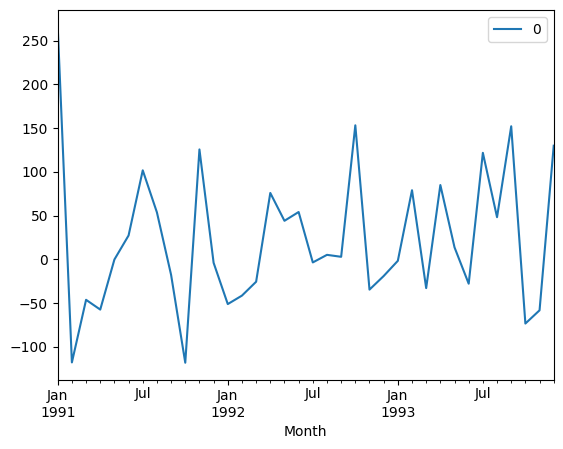

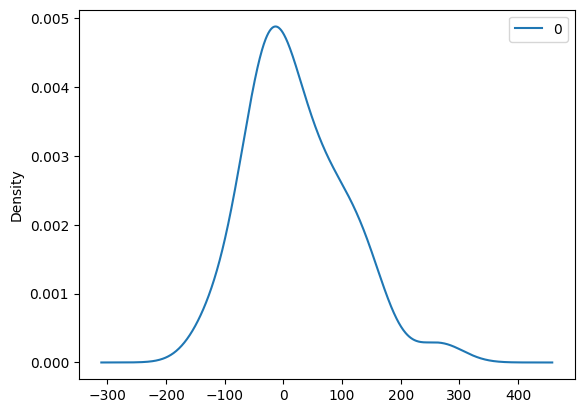

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [6]:
# ARIMA()함수를 호출하여 sales 데이터셋에 대한 예측
from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

#시간을 표현하는 함수 정의
def parser(x):

    # strptime()은 날짜와 시간 정보를 문자열로 바꿔주는 메서드
    return datetime.strptime('199'+x, '%Y-%m')

series= read_csv('/content/drive/MyDrive/ESSA/sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
model= ARIMA(series, order=(5,1,0))
model_fit= model.fit()
print(model_fit.summary())

residuals= DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

/tmp/ipykernel_25388/2842582347.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series= read_csv('/content/drive/MyDrive/ESSA/sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
/tmp/ipykernel_25388/2842582347.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f'% (yhat, obs))


predicted=352.855343, expected=346.300000
predicted=277.398036, expected=329.700000
predicted=368.753734, expected=445.400000
predicted=331.773635, expected=325.900000
predicted=372.070407, expected=449.300000
predicted=360.020872, expected=411.300000
predicted=454.526230, expected=417.400000
predicted=388.690699, expected=545.500000
predicted=437.632447, expected=477.600000
predicted=516.437624, expected=687.000000
predicted=520.916191, expected=435.300000
predicted=675.594647, expected=587.300000
predicted=505.201016, expected=676.900000
Test MSE: 9118.818


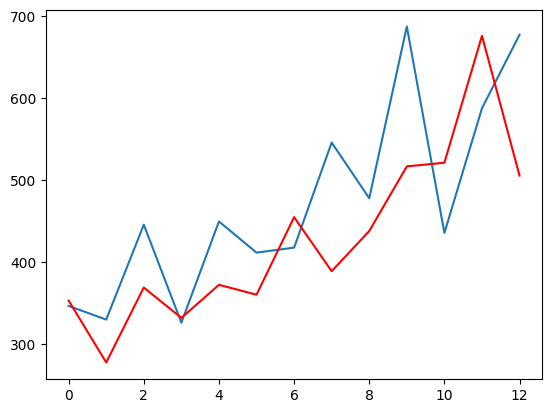

In [7]:
# statsmodels 라이브러리를 이용한 sales 데이터셋 예측
import numpy as np
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

series= read_csv('/content/drive/MyDrive/ESSA/sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
X= series.values
X=  np.nan_to_num(X)
size= int(len(X)*0.66)

# train, test분리
train, test= X[0:size], X[size:len(X)]
history= [x for x in train]
predictions= list()
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit= model.fit()

    # forecast()로 예측수행
    output= model_fit.forecast()
    yhat= output[0] #출력 결과 저장
    predictions.append(yhat)
    obs= test[t]
    history.append(obs)
    # 모델 실행 결과를 predicted로 출력, test로 분리해둔 데이터를 expected로 사용하여 출력
    print('predicted=%f, expected=%f'% (yhat, obs))

error= mean_squared_error(test, predictions)
print('Test MSE: %.3f' % error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()


- 실제 데이터(빨강), 모형 실행결과(파랑)
- 데이터가 우상향 추세 -> 향후에도 자전거 판매 증가할것을 예측

###7.3 순환신경망 (RNN)
RNN(Recurrent Neural Network) : 시간적으로 연속성이 있는 데이터를 처리하려고 만든 인공신경망
- recurrent(반복되는) : 이전 은닉층이 현재 은닉층의 입력 되면서 반복되는 순환구조 갖는다.
- 특징 : 기억을 가짐, 기억= 현재까지 입력데이터를 요약한 정보
  - 최종적으로 남겨진 기억은 모든 입력전체를 요약한 정보가 됨
  - 첫번째 입력이 들어올 시 첫번째 기억이 만들어지고 ..-> RNN은 외부입력과 자신의 이전 상태를 입력받아 현상태 갱신

- RNN 유형
  1. 일대일 : 순환이 없어서 RNN이라고는 안함, 순방향 네트워크가 대표 사례
  2. 일대다 : 입력이 하나, 출력이 다수인 구조
    - 이미지를 입력해 이미지에 대한 설명을 문장으로 출력하는 이미지 캡션
  3. 다대일 : 입력 다수, 출력 하나인 구조
    - 문장을 입력해서 긍정/부정을 출력하는 감성분석기에서 사용

> 다대일 모델 구현 코드
```
# 임베딩 처리
self.em= nn.Embedding(len(TEXT, vocab.stoi), embedding_dim)
self.rnn= nn.RNNCell(input_dim, hidden_size)
self.fc1= nn.Linear(hidden_size, 256) # 완전연결층
self.fc2= nn.Linear(256, 3) # 출력층
```
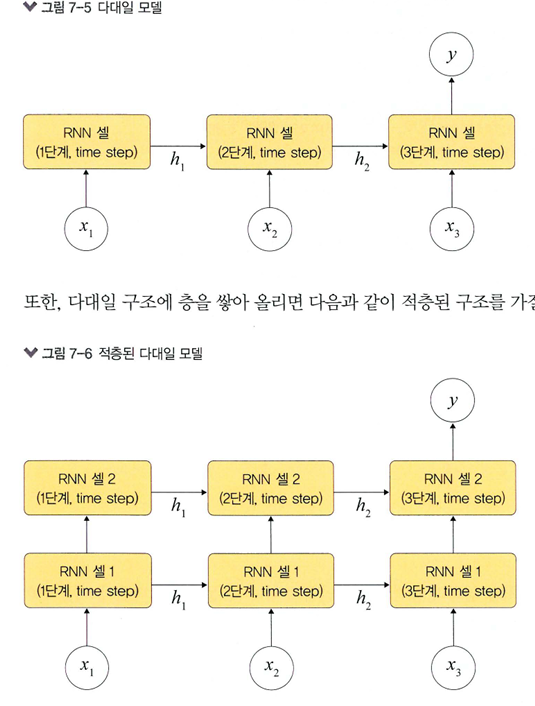
  

4. 다대다
: 입력과 출력이 다수, 언어를 번역하는 자동번역기 등
```
Seq2Seq(
(encoder): Encoder(
(embedding): Embedding(7855, 256)
(rnn): LSTM(256, 512, num_layers=2 , dropout=0 .5 )
(dropout): Dropout( p=0 .5, inplace=False))

(decoder): Decoder(
(embedding): Embedding(5893, 256)
(rnn): LSTM(256, 512, num_layers=2 , dropout=0 .5 )
(fc_out): Linear( in_features=51ι out_features=5893, bias=True )
(dropout): Dropout( p=0.5 , inplace=False)))
```

  5. 동기화 다대다 : 입력과 출력이 다수
    - 프레임 수준의 비디오 분류


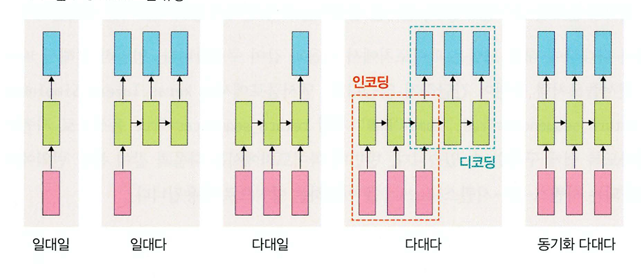


**7.3.1 RNN계층과 셀**
- RNN계층이 입력된 배치 순서로 모두 처리하는 것과 달리 RNN셀은 오직 하나의 단계만 처리
- RNN셀= RNN계층의 for loop구문을 갖는 구조
- RNN계층은 셀 래핑하여 동일 셀을 여러 단계에 적용
  - 셀은 실제 계산에 사용되는 RNN계층 구성요소, 단일입력과 과거 상태를 가져와서 출력과 새로운 상태 생성
- 셀 유형
  - nn.RNNcell : SimpleRNN계층에 대응되는 RNN셀
  - nn.GRUCell : GRU계층에 대응되는 GRU셀
  - nn.LSTMCell : LSTM계층에 대응되는 LSTM셀

> RNN활용분야 : 자연어처리, 음성인식, 단어 의미판단, 손글씨, 센서 데이터 등 처리